#### Prediction #2 on practitioner-documented workflows: the fragmentation index over APQC process sequences
#### By: Peyman Shahidi
#### Created: 2026-08-01

**Idea.** The empirical fragmentation index in the main text is computed over a workflow ordering that a
language model imputed. Appendices on the APQC framework and on process-mining logs establish that the
imputation recovers real sequence structure, but Prediction~\#2 itself still rests on it.

This notebook removes the imputation from the estimating equation. APQC's Process Classification Framework
supplies process sequences that practitioners wrote down, so if we can attach exposure and execution labels
to APQC's steps we can compute the fragmentation index over an ordering no model produced, and re-run the
fragmentation regression on it.

**The one thing that has to be borrowed.** There is no exposure or execution measure defined over PCF
elements, which is why the paper works with O\*NET in the first place. We therefore transfer the labels: each
PCF step is matched to its nearest O\*NET task in `all-mpnet-base-v2` embedding space and inherits that task's
Eloundou exposure label (E0/E1/E2) and Anthropic Economic Index execution label (Manual/Augmentation/
Automation). The ordering is APQC's; only the labels come from O\*NET.

**Unit of analysis.** A PCF Process Group (hierarchy level 2) together with the ordered leaf elements
beneath it, linearised by depth-first traversal of APQC's own child ordering. There are 74 such groups with a
mean of 21.9 leaves, which is close to the paper's 872 occupations with a mean of 20.6 tasks. Level-3
Processes (n=248, mean 6.1 leaves) are reported as a secondary, shorter-sequence unit.

**Specification.** Identical to `onet_fragmentationIndex.ipynb`: EFI Definition~1 counts a step as AI-able
when it is E1- or E2-exposed and merges consecutive AI-able steps into one block, so
$\text{EFI} = (\text{blocks})/(\text{steps})$; the dependent variable is the share of steps executed by AI
(Augmentation or Automation); the exposure control is the E1 share. All three are standardised within the
sample, so coefficients read in standard deviations.

**Outputs.** `data/computed_objects/apqc_pcf_fragmentation/` and `writeup/plots/apqc_pcf_fragmentation/`.

In [1]:
#Python
import os, warnings
import numpy as np, pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 200); pd.set_option('display.width', 220)

MIN_STEPS   = 3          # a unit needs at least this many steps, matching the paper's >=3 tasks filter
SIM_FLOOR   = None       # primary spec keeps every match; robustness re-runs with a cosine floor
EMBED_MODEL = 'all-mpnet-base-v2'

main_folder_path  = ".."
input_data_path   = f"{main_folder_path}/data"
onet_file         = f"{input_data_path}/computed_objects/ONET_Eloundou_Anthropic_GPT/ONET_Eloundou_Anthropic_GPT.csv"
pcf_file          = f"{input_data_path}/computed_objects/apqc_pcf_ordering/pcf_elements.csv"
embedding_model_path = f"{input_data_path}/sentence-transformers/{EMBED_MODEL}"

output_data_path  = f"{input_data_path}/computed_objects/apqc_pcf_fragmentation"
output_plot_path  = f"{main_folder_path}/writeup/plots/apqc_pcf_fragmentation"
output_table_path = f"{main_folder_path}/writeup/tables"
for p in [output_data_path, output_plot_path, output_table_path]:
    os.makedirs(p, exist_ok=True)

# 1) The two sides of the match

The O\*NET side is the labelled task universe used throughout the paper: 17,920 distinct tasks, each carrying
an Eloundou exposure label and an Anthropic Economic Index execution label. Labels are constant within a Task
ID, so the task is the natural matching target.

The PCF side is the 1,622 leaf elements of the cross-industry framework, the steps that are not themselves
decomposed further. We embed the leaf's name together with its description, and the O\*NET task statement on
its own. Occupation context is deliberately left out of the O\*NET text: adding it would pull matches toward
occupational vocabulary rather than the work being described.

In [2]:
# --- O*NET side: the labelled task universe ---
onet = pd.read_csv(onet_file)
tasks = (onet.dropna(subset=['human_labels'])
         .drop_duplicates('Task ID')[['Task ID', 'Task Title', 'human_labels', 'label',
                                      'O*NET-SOC Code', 'Occupation Title']]
         .reset_index(drop=True))
print(f"O*NET tasks with labels: {len(tasks):,}")
print("  exposure :", tasks['human_labels'].value_counts().to_dict())
print("  execution:", tasks['label'].value_counts().to_dict())

# --- PCF side: leaf elements of the cross-industry framework ---
pcf = pd.read_csv(pcf_file, dtype={'hierarchy_id': str, 'parent_id': str})
pcf['is_leaf'] = ~pcf['hierarchy_id'].isin(pcf['parent_id'].dropna())
leaves = pcf[pcf['is_leaf']].copy()
leaves['text'] = (leaves['name'].fillna('') + ': ' + leaves['description'].fillna('')).str.strip(': ')
print(f"\nPCF leaf elements: {len(leaves):,} (of {len(pcf):,} elements)")
print("  by level:", leaves['level'].value_counts().sort_index().to_dict())

# depth-first position: sort key is the tuple of integer components of the hierarchy id
leaves['sort_key'] = leaves['hierarchy_id'].apply(lambda h: tuple(int(x) for x in h.split('.')))
leaves = leaves.sort_values('sort_key').reset_index(drop=True)

O*NET tasks with labels: 17,131
  exposure : {'E0': 9313, 'E2': 5287, 'E1': 2531}
  execution: {'Manual': 14939, 'Augmentation': 1548, 'Automation': 644}

PCF leaf elements: 1,622 (of 2,017 elements)
  by level: {3: 114, 4: 1293, 5: 215}


In [3]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer(embedding_model_path, device='cpu')

E_task = model.encode(tasks['Task Title'].astype(str).tolist(), batch_size=64,
                      normalize_embeddings=True, show_progress_bar=True, convert_to_numpy=True).astype(np.float32)
E_leaf = model.encode(leaves['text'].astype(str).tolist(), batch_size=64,
                      normalize_embeddings=True, show_progress_bar=True, convert_to_numpy=True).astype(np.float32)
print("embeddings:", E_leaf.shape, E_task.shape)

# nearest O*NET task for every PCF leaf (cosine, since both sides are L2-normalised)
S = E_leaf @ E_task.T
best = S.argmax(axis=1)
leaves['similarity']   = S[np.arange(len(leaves)), best]
leaves['match_task_id']    = tasks['Task ID'].values[best]
leaves['match_task_title'] = tasks['Task Title'].values[best]
leaves['match_occupation'] = tasks['Occupation Title'].values[best]
leaves['human_labels']     = tasks['human_labels'].values[best]
leaves['label']            = tasks['label'].values[best]
leaves.drop(columns=['sort_key']).to_csv(f"{output_data_path}/pcf_leaf_matches.csv", index=False)

print(f"\ncosine similarity of best match: mean {leaves['similarity'].mean():.3f} | "
      f"median {leaves['similarity'].median():.3f} | p10 {leaves['similarity'].quantile(.1):.3f} | "
      f"p90 {leaves['similarity'].quantile(.9):.3f}")
print("distinct O*NET tasks used:", leaves['match_task_id'].nunique(),
      f"({leaves['match_task_id'].nunique()/len(leaves):.0%} of leaves get a distinct match)")
print("\ninherited label composition (PCF leaves):")
print("  exposure :", leaves['human_labels'].value_counts(normalize=True).round(3).to_dict())
print("  execution:", leaves['label'].value_counts(normalize=True).round(3).to_dict())
print("\nfor comparison, the O*NET task universe:")
print("  exposure :", tasks['human_labels'].value_counts(normalize=True).round(3).to_dict())
print("  execution:", tasks['label'].value_counts(normalize=True).round(3).to_dict())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: ../data/sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/268 [00:00<?, ?it/s]

Batches:   0%|          | 0/26 [00:00<?, ?it/s]

embeddings: (1622, 768) (17131, 768)

cosine similarity of best match: mean 0.643 | median 0.641 | p10 0.554 | p90 0.735
distinct O*NET tasks used: 878 (54% of leaves get a distinct match)

inherited label composition (PCF leaves):
  exposure : {'E2': 0.517, 'E1': 0.277, 'E0': 0.206}
  execution: {'Manual': 0.761, 'Augmentation': 0.176, 'Automation': 0.062}

for comparison, the O*NET task universe:
  exposure : {'E0': 0.544, 'E2': 0.309, 'E1': 0.148}
  execution: {'Manual': 0.872, 'Augmentation': 0.09, 'Automation': 0.038}


=== best and worst matches, for judging the transfer ===

--- CLOSEST 12 ---
  0.85 | Identify potential customers                  -> Identify prospective customers by using business directories
  0.85 | Create training and communication plans       -> Establish and execute a project communication plan.
  0.84 | Modify/revise and approve project plan        -> Initiate, review, or approve modifications to project plans.
  0.84 | Recognize need to disposition hazardous mate  -> Dispose of hazardous waste in an appropriate manner.
  0.83 | Understand consumer needs and historical beh  -> Collect and analyze data on customer demographics, preferenc
  0.83 | Receive/Deposit customer payments             -> Receive and process customer payments.
  0.83 | Respond to customer problems, requests, and   -> Respond to customer inquiries or complaints.
  0.83 | Train employees on appropriate regulatory re  -> Provide regulatory compliance training to employees.
  0.83 | Prepare tax returns      

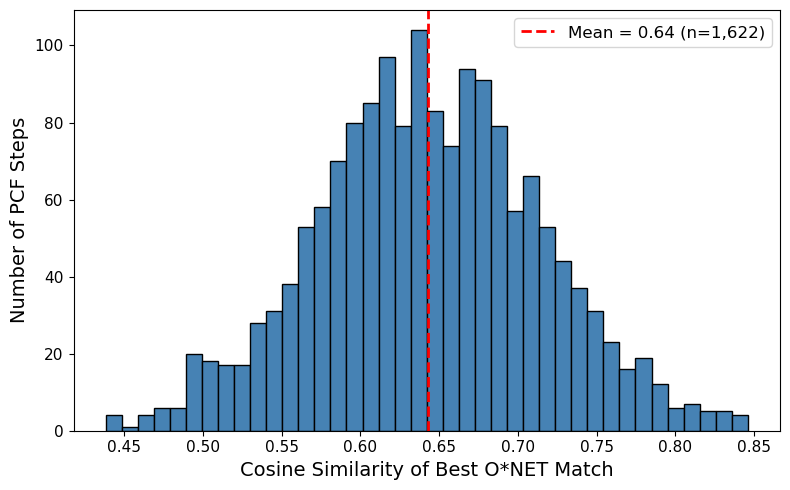

In [4]:
print("=== best and worst matches, for judging the transfer ===\n")
for lab, sub in [('CLOSEST 12', leaves.nlargest(12, 'similarity')),
                 ('WEAKEST 12', leaves.nsmallest(12, 'similarity'))]:
    print(f"--- {lab} ---")
    for _, r in sub.iterrows():
        print(f"  {r['similarity']:.2f} | {r['name'][:44]:<45} -> {r['match_task_title'][:60]}")
    print()

print("=== a random sample at the median ===")
mid = leaves[(leaves['similarity'] > leaves['similarity'].quantile(.45)) &
             (leaves['similarity'] < leaves['similarity'].quantile(.55))]
for _, r in mid.sample(10, random_state=1).iterrows():
    print(f"  {r['similarity']:.2f} | {r['name'][:44]:<45} -> {r['match_task_title'][:60]}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(leaves['similarity'], bins=40, color='steelblue', edgecolor='black')
ax.axvline(leaves['similarity'].mean(), color='red', ls='--', lw=2,
           label=f"Mean = {leaves['similarity'].mean():.2f} (n={len(leaves):,})")
ax.set_xlabel("Cosine Similarity of Best O*NET Match", fontsize=14)
ax.set_ylabel("Number of PCF Steps", fontsize=14)
ax.tick_params(labelsize=11); ax.legend(fontsize=12)
fig.tight_layout()
fig.savefig(f"{output_plot_path}/match_similarity.png", dpi=300, bbox_inches='tight')
plt.show()

# 2) The fragmentation index over APQC's ordering

The construction is copied from `onet_fragmentationIndex.ipynb` and differs only in what defines a unit and
what defines the order within it. A step counts as AI-able when its inherited exposure label is E1 or E2
(Definition~1); consecutive AI-able steps merge into a single block; and

$$\text{EFI} = \frac{\text{number of blocks}}{\text{number of steps}},$$

implemented exactly as in the paper by setting a switch counter to zero when a step and its successor are
both AI-able and averaging the counter over the unit. A unit whose AI-able steps are perfectly clustered
approaches a low EFI; one whose AI-able steps alternate with manual steps approaches 1.

The order within a unit is APQC's depth-first child ordering, which no model produced.

In [5]:
def unit_id(hierarchy_id, level):
    """The level-`level` ancestor of a leaf: '4.2.4.3' -> '4.0' (L1), '4.2' (L2), '4.2.4' (L3)."""
    parts = hierarchy_id.split('.')
    if len(parts) < level:
        return None
    return f"{parts[0]}.0" if level == 1 else '.'.join(parts[:level])

def build_units(df, level, min_steps=MIN_STEPS):
    """One row per unit: EFI (Definition 1), AI-execution share, exposure shares, step count."""
    d = df.copy()
    d['unit'] = d['hierarchy_id'].map(lambda h: unit_id(h, level))
    d = d.dropna(subset=['unit']).sort_values('sort_key').reset_index(drop=True)

    # EFI Definition 1: exposure-based, E1 or E2
    d['is_ai'] = d['human_labels'].isin(['E1', 'E2']).astype(int)
    d['next_is_ai'] = d.groupby('unit')['is_ai'].shift(-1).fillna(0).astype(int)
    d['num_switches'] = 1
    d.loc[(d['is_ai'] == 1) & (d['next_is_ai'] == 1), 'num_switches'] = 0

    out = (d.groupby('unit')
           .agg(num_steps=('hierarchy_id', 'size'),
                fragmentation_index=('num_switches', 'mean'),
                ai_fraction=('label', lambda s: s.isin(['Augmentation', 'Automation']).mean()),
                ai_exposure=('human_labels', lambda s: (s == 'E1').mean()),
                aiExposure_E1E2=('human_labels', lambda s: s.isin(['E1', 'E2']).mean()),
                mean_similarity=('similarity', 'mean'))
           .reset_index())
    out['category'] = out['unit'].str.split('.').str[0].astype(int)
    names = dict(zip(pcf['hierarchy_id'], pcf['name']))
    out['unit_name'] = out['unit'].map(names)
    return out[out['num_steps'] >= min_steps].reset_index(drop=True)

units_L2 = build_units(leaves, 2)
units_L3 = build_units(leaves, 3)
units_L2.to_csv(f"{output_data_path}/units_level2.csv", index=False)
units_L3.to_csv(f"{output_data_path}/units_level3.csv", index=False)

for nm, u in [('Level 2 (Process Group)', units_L2), ('Level 3 (Process)', units_L3)]:
    print(f"{nm}: n={len(u)} | steps per unit mean {u['num_steps'].mean():.1f} "
          f"(median {u['num_steps'].median():.0f}) | EFI mean {u['fragmentation_index'].mean():.3f} "
          f"| AI execution {u['ai_fraction'].mean():.3f} | E1 exposure {u['ai_exposure'].mean():.3f} "
          f"| E1|E2 {u['aiExposure_E1E2'].mean():.3f}")

print("\nfor reference, the paper's occupation sample (from the published table): "
      "n=872, mean 20.6 tasks")
print("\nLevel-2 units, EFI distribution:")
print(units_L2['fragmentation_index'].describe().round(3).to_string())

Level 2 (Process Group): n=73 | steps per unit mean 22.2 (median 19) | EFI mean 0.422 | AI execution 0.213 | E1 exposure 0.275 | E1|E2 0.774
Level 3 (Process): n=231 | steps per unit mean 6.4 (median 6) | EFI mean 0.475 | AI execution 0.239 | E1 exposure 0.278 | E1|E2 0.789

for reference, the paper's occupation sample (from the published table): n=872, mean 20.6 tasks

Level-2 units, EFI distribution:
count    73.000
mean      0.422
std       0.260
min       0.027
25%       0.214
50%       0.382
75%       0.600
max       1.000


# 3) The fragmentation regression

Specification as in the main text:

$$\text{ai\_execution}_u = \beta_0 + \beta_1 \,\text{AI exposure}_u + \beta_2 \,\text{EFI}_u + \varepsilon_u,$$

with all three variables standardised within the sample so coefficients are in standard deviations.
Prediction~\#2 is $\beta_1 > 0$ and $\beta_2 < 0$: holding exposure fixed, workflows whose AI-able steps are
more dispersed realise less AI execution.

The paper reports $\beta_1 = 0.26$ and $\beta_2 = -0.38$ without fixed effects, and $-0.32$ and $-0.23$ for
the EFI coefficient under SOC major- and minor-group fixed effects. Here the analogue of a SOC group is the
PCF Category, of which there are 13.

In [6]:
def run_fragmentation_regression(u, label, with_fe=True):
    d = u.copy()
    for c in ['ai_fraction', 'ai_exposure', 'fragmentation_index']:
        d[c] = (d[c] - d[c].mean()) / d[c].std()
    d['category'] = d['category'].astype('object')
    specs = [('No FE', 'ai_fraction ~ fragmentation_index + ai_exposure')]
    if with_fe:
        specs.append(('Category FE', 'ai_fraction ~ fragmentation_index + ai_exposure + C(category)'))
    rows = []
    for nm, f in specs:
        m = smf.ols(f, data=d).fit(cov_type='HC1')
        rows.append({'sample': label, 'spec': nm, 'n': int(m.nobs),
                     'b_exposure': m.params['ai_exposure'], 'se_exposure': m.bse['ai_exposure'],
                     'p_exposure': m.pvalues['ai_exposure'],
                     'b_EFI': m.params['fragmentation_index'], 'se_EFI': m.bse['fragmentation_index'],
                     'p_EFI': m.pvalues['fragmentation_index'], 'r2': m.rsquared})
    return pd.DataFrame(rows)

def stars(p):
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''

res = pd.concat([run_fragmentation_regression(units_L2, 'Level 2 (Process Group)'),
                 run_fragmentation_regression(units_L3, 'Level 3 (Process)')], ignore_index=True)
res.to_csv(f"{output_data_path}/fragmentation_regression.csv", index=False)

print("Prediction #2:  AI exposure > 0,  EFI < 0\n")
print(f"{'sample':<26}{'spec':<14}{'n':>5}{'AI exposure':>18}{'EFI':>18}{'R2':>8}")
for _, r in res.iterrows():
    print(f"{r['sample']:<26}{r['spec']:<14}{int(r['n']):>5}"
          f"{r['b_exposure']:>13.3f}{stars(r['p_exposure']):<5}"
          f"{r['b_EFI']:>13.3f}{stars(r['p_EFI']):<5}{r['r2']:>8.3f}")
    print(f"{'':<45}({r['se_exposure']:.3f}){'':<7}({r['se_EFI']:.3f})")

print("\npaper, O*NET workflows (Table: fragmentation_index_regression_exposure):")
print(f"{'occupations':<26}{'No FE':<14}{872:>5}{0.26:>13.3f}{'***':<5}{-0.38:>13.3f}{'***':<5}{0.35:>8.3f}")
print(f"{'occupations':<26}{'Major FE':<14}{872:>5}{0.10:>13.3f}{'**':<5}{-0.32:>13.3f}{'***':<5}{0.63:>8.3f}")
print(f"{'occupations':<26}{'Minor FE':<14}{872:>5}{0.08:>13.3f}{'*':<5}{-0.23:>13.3f}{'***':<5}{0.71:>8.3f}")

Prediction #2:  AI exposure > 0,  EFI < 0

sample                    spec              n       AI exposure               EFI      R2
Level 2 (Process Group)   No FE            73       -0.217*           -0.612***     0.322
                                             (0.129)       (0.110)
Level 2 (Process Group)   Category FE      73       -0.057            -0.473***     0.483
                                             (0.168)       (0.122)
Level 3 (Process)         No FE           231       -0.145*           -0.367***     0.110
                                             (0.080)       (0.069)
Level 3 (Process)         Category FE     231       -0.084            -0.253***     0.266
                                             (0.077)       (0.073)

paper, O*NET workflows (Table: fragmentation_index_regression_exposure):
occupations               No FE           872        0.260***         -0.380***     0.350
occupations               Major FE        872        0.100**          -0.32

=== (a) restricting to better matches ===
  floor None  steps 1,622 units  73 | exposure -0.217 | EFI -0.612***
  floor 0.4   steps 1,622 units  73 | exposure -0.217 | EFI -0.612***
  floor 0.45  steps 1,618 units  73 | exposure -0.213 | EFI -0.611***
  floor 0.5   steps 1,580 units  73 | exposure -0.221 | EFI -0.625***
  floor 0.55  steps 1,472 units  73 | exposure -0.236 | EFI -0.619***

=== (b) placebo: reshuffle step order within each unit (1,000 draws) ===


  observed EFI coefficient -0.612 | reshuffle null mean -0.599 (sd 0.019) | z = -0.70 | p = 0.2428


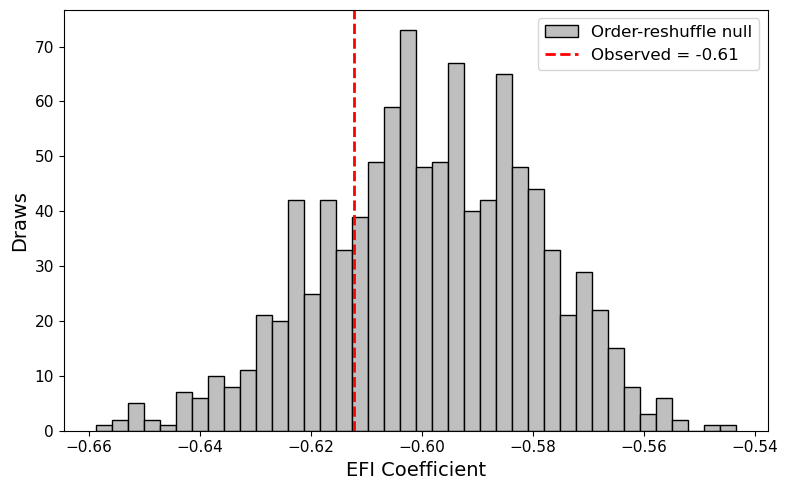

In [7]:
# Robustness: (a) drop weak matches, (b) reshuffle the ordering to check the EFI carries positional content
print("=== (a) restricting to better matches ===")
rob = []
for floor in [None, 0.40, 0.45, 0.50, 0.55]:
    sub = leaves if floor is None else leaves[leaves['similarity'] >= floor]
    u = build_units(sub, 2)
    if len(u) < 15:
        print(f"  floor {floor}: only {len(u)} units, skipped"); continue
    r = run_fragmentation_regression(u, f"floor={floor}", with_fe=False).iloc[0]
    rob.append({'floor': floor, 'steps_kept': len(sub), 'units': int(r['n']),
                'b_exposure': r['b_exposure'], 'b_EFI': r['b_EFI'], 'p_EFI': r['p_EFI']})
    print(f"  floor {str(floor):<5} steps {len(sub):>5,} units {int(r['n']):>3} | "
          f"exposure {r['b_exposure']:+.3f} | EFI {r['b_EFI']:+.3f}{stars(r['p_EFI'])}")
pd.DataFrame(rob).to_csv(f"{output_data_path}/robustness_similarity_floor.csv", index=False)

print("\n=== (b) placebo: reshuffle step order within each unit (1,000 draws) ===")
rng = np.random.default_rng(123)
obs = run_fragmentation_regression(units_L2, 'obs', with_fe=False).iloc[0]['b_EFI']
draws = []
for _ in range(1000):
    d = leaves.copy()
    d['unit_tmp'] = d['hierarchy_id'].map(lambda h: unit_id(h, 2))
    d['r'] = rng.random(len(d))
    d = d.sort_values(['unit_tmp', 'r'])
    d['sort_key'] = range(len(d))            # reshuffled order within unit
    u = build_units(d, 2)
    draws.append(run_fragmentation_regression(u, 'null', with_fe=False).iloc[0]['b_EFI'])
draws = np.array(draws)
p = (1 + int((draws <= obs).sum())) / 1001
print(f"  observed EFI coefficient {obs:+.3f} | reshuffle null mean {draws.mean():+.3f} "
      f"(sd {draws.std(ddof=1):.3f}) | z = {(obs - draws.mean())/draws.std(ddof=1):.2f} | p = {p:.4f}")
pd.DataFrame({'b_EFI_null': draws}).to_csv(f"{output_data_path}/placebo_reshuffle_draws.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(draws, bins=40, color='0.75', edgecolor='black', label='Order-reshuffle null')
ax.axvline(obs, color='red', ls='--', lw=2, label=f'Observed = {obs:+.2f}')
ax.set_xlabel("EFI Coefficient", fontsize=14); ax.set_ylabel("Draws", fontsize=14)
ax.tick_params(labelsize=11); ax.legend(fontsize=12)
fig.tight_layout()
fig.savefig(f"{output_plot_path}/efi_coefficient_placebo.png", dpi=300, bbox_inches='tight')
plt.show()

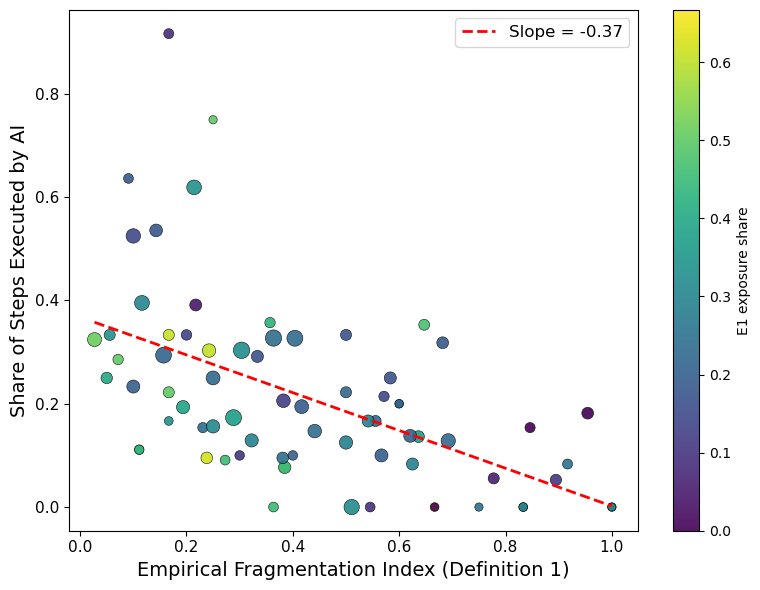

most and least fragmented Process Groups

--- LEAST fragmented (clustered AI-able steps) ---
  EFI 0.03 | AI exec 0.32 | E1|E2 1.00 | n=37 | 7.1 Develop and manage human resources (HR) planning
  EFI 0.05 | AI exec 0.25 | E1|E2 1.00 | n=20 | 13.5 Develop and manage enterprise-wide knowledge man
  EFI 0.06 | AI exec 0.33 | E1|E2 1.00 | n=18 | 2.2 Generate and define new product/service ideas
  EFI 0.07 | AI exec 0.29 | E1|E2 1.00 | n=14 | 7.7 Manage employee information and analytics
  EFI 0.09 | AI exec 0.64 | E1|E2 1.00 | n=11 | 13.8 Develop, Manage, and Deliver Analytics
  EFI 0.10 | AI exec 0.23 | E1|E2 0.97 | n=30 | 13.2 Manage portfolio, program, and project
  EFI 0.10 | AI exec 0.53 | E1|E2 0.95 | n=40 | 3.2 Develop marketing strategy
  EFI 0.11 | AI exec 0.11 | E1|E2 1.00 | n= 9 | 1.4 Develop and maintain business models

--- MOST fragmented (dispersed AI-able steps) ---
  EFI 1.00 | AI exec 0.00 | E1|E2 0.20 | n= 5 | 7.4 Manage employee relations
  EFI 1.00 | AI exec 0.00 | E1|

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
u = units_L2
sc = ax.scatter(u['fragmentation_index'], u['ai_fraction'], s=28 + 2 * u['num_steps'],
                c=u['ai_exposure'], cmap='viridis', edgecolor='black', linewidth=0.4, alpha=0.9)
b = np.polyfit(u['fragmentation_index'], u['ai_fraction'], 1)
xs = np.linspace(u['fragmentation_index'].min(), u['fragmentation_index'].max(), 50)
ax.plot(xs, np.polyval(b, xs), color='red', ls='--', lw=2, label=f'Slope = {b[0]:+.2f}')
plt.colorbar(sc, ax=ax, label='E1 exposure share')
ax.set_xlabel("Empirical Fragmentation Index (Definition 1)", fontsize=14)
ax.set_ylabel("Share of Steps Executed by AI", fontsize=14)
ax.tick_params(labelsize=11); ax.legend(fontsize=12)
fig.tight_layout()
fig.savefig(f"{output_plot_path}/efi_vs_ai_execution.png", dpi=300, bbox_inches='tight')
plt.show()

print("most and least fragmented Process Groups")
for lab, sub in [('LEAST fragmented (clustered AI-able steps)', u.nsmallest(8, 'fragmentation_index')),
                 ('MOST fragmented (dispersed AI-able steps)', u.nlargest(8, 'fragmentation_index'))]:
    print(f"\n--- {lab} ---")
    for _, r in sub.iterrows():
        print(f"  EFI {r['fragmentation_index']:.2f} | AI exec {r['ai_fraction']:.2f} | "
              f"E1|E2 {r['aiExposure_E1E2']:.2f} | n={int(r['num_steps']):>2} | "
              f"{r['unit']} {str(r['unit_name'])[:48]}")
print("\nSaved:")
for f in sorted(os.listdir(output_data_path)):
    print("  data ->", f"{output_data_path}/{f}")
for f in sorted(os.listdir(output_plot_path)):
    print("  plot ->", f"{output_plot_path}/{f}")

# 4) Composition versus arrangement

The fragmentation index is meant to capture *where* the AI-able steps sit, but it is built from the same
labels that determine *how many* of them there are. For a unit with $n$ steps of which a share $p$ are
AI-able, EFI equals one minus the count of adjacent AI-able pairs over $n$, and under an arbitrary
arrangement that is approximately $1 - p^2$. EFI therefore tracks the exposure share mechanically, and only
its residual variation reflects clustering.

The estimating equation in the main text controls for the **E1** share while EFI is built from **E1 or E2**,
so the E1$|$E2 composition channel is left inside the EFI coefficient. This section separates the two by
adding the E1$|$E2 share as a control, so that EFI identifies arrangement holding density fixed, and tests
both specifications against a null in which step order is randomised within each unit while the labels, and
therefore the composition, stay exactly as observed.

Both samples are put through the identical procedure: the paper's O\*NET occupations ordered by their
GPT-imputed task positions, and the APQC process groups ordered by APQC's own documented sequence.

In [9]:
def to_panel(df, unit_col, order_col, fe_col):
    """Reduce a step-level frame to per-unit arrays. EFI is the only order-dependent object."""
    d = df.sort_values([unit_col, order_col])
    d = d.assign(is_ai=d['human_labels'].isin(['E1', 'E2']).astype(int),
                 exec_ai=d['label'].isin(['Augmentation', 'Automation']).astype(int),
                 is_e1=(d['human_labels'] == 'E1').astype(int))
    seqs, rows = {}, []
    for u, g in d.groupby(unit_col, sort=False):
        if len(g) < MIN_STEPS:
            continue
        seqs[u] = g['is_ai'].to_numpy()
        rows.append({'unit': u, 'n': len(g), 'ai': g['exec_ai'].mean(),
                     'e1': g['is_e1'].mean(), 'e12': g['is_ai'].mean(),
                     'fe': g[fe_col].iloc[0]})
    return pd.DataFrame(rows), seqs

def efi_from(seq):
    """Blocks per step: 1 minus the share of positions whose successor is also AI-able."""
    return 1.0 - float((seq[:-1] & seq[1:]).sum()) / len(seq)

SPECS = {'paper spec': 'ai ~ efi + e1', '+ E1|E2 control': 'ai ~ efi + e1 + e12'}

def fit_spec(panel, formula, fe=False):
    z = panel.copy()
    for c in ['ai', 'e1', 'efi', 'e12']:
        z[c] = (z[c] - z[c].mean()) / z[c].std()
    z['fe'] = z['fe'].astype('object')
    f = formula + (' + C(fe)' if fe else '')
    return smf.ols(f, data=z).fit(cov_type='HC1')

# --- O*NET occupations, ordered by the GPT-imputed task position ---
onet_full = pd.read_csv(onet_file).dropna(subset=['human_labels']).copy()
onet_full['Task Position'] = pd.to_numeric(onet_full['Task Position'], errors='coerce')
onet_full = onet_full.dropna(subset=['Task Position'])
panel_onet, seq_onet = to_panel(onet_full, 'O*NET-SOC Code', 'Task Position', 'Major_Group_Code')

# --- APQC process groups, ordered by APQC's documented sequence ---
apqc = leaves.copy()
apqc['unit_l2'] = apqc['hierarchy_id'].map(lambda h: unit_id(h, 2))
apqc['cat'] = apqc['hierarchy_id'].str.split('.').str[0].astype(int)
panel_apqc, seq_apqc = to_panel(apqc, 'unit_l2', 'sort_key', 'cat')

SAMPLES = {'O*NET occupations (GPT order)': (panel_onet, seq_onet),
           'APQC process groups (practitioner order)': (panel_apqc, seq_apqc)}

obs_rows = []
for sname, (panel, seqs) in SAMPLES.items():
    panel = panel.assign(efi=panel['unit'].map(lambda u: efi_from(seqs[u])))
    SAMPLES[sname] = (panel, seqs)
    print(f"--- {sname}: n={len(panel)} | mean steps {panel['n'].mean():.1f} | "
          f"E1|E2 share {panel['e12'].mean():.3f} | EFI {panel['efi'].mean():.3f}")
    r2 = smf.ols('efi ~ e12 + I(e12**2)', data=panel).fit().rsquared
    print(f"    EFI explained by the E1|E2 share alone: R2 = {r2:.3f}")
    for sn, f in SPECS.items():
        for fe in [False, True]:
            m = fit_spec(panel, f, fe)
            obs_rows.append({'sample': sname, 'spec': sn, 'fe': 'FE' if fe else 'No FE',
                             'n': int(m.nobs), 'b_efi': m.params['efi'], 'se_efi': m.bse['efi'],
                             'p_efi': m.pvalues['efi'], 'b_e1': m.params['e1'],
                             'b_e12': m.params.get('e12', np.nan), 'r2': m.rsquared})
    print()

obs = pd.DataFrame(obs_rows)
obs.to_csv(f"{output_data_path}/composition_vs_arrangement_observed.csv", index=False)
print(f"{'sample':<44}{'spec':<18}{'FE':<7}{'n':>5}{'EFI':>16}{'E1':>9}{'E1|E2':>9}")
for _, r in obs.iterrows():
    e12 = '' if pd.isna(r['b_e12']) else f"{r['b_e12']:+.3f}"
    print(f"{r['sample']:<44}{r['spec']:<18}{r['fe']:<7}{int(r['n']):>5}"
          f"{r['b_efi']:>11.3f}{stars(r['p_efi']):<5}{r['b_e1']:>+9.3f}{e12:>9}")

--- O*NET occupations (GPT order): n=871 | mean steps 19.7 | E1|E2 share 0.453 | EFI 0.713
    EFI explained by the E1|E2 share alone: R2 = 0.971

--- APQC process groups (practitioner order): n=73 | mean steps 22.2 | E1|E2 share 0.774 | EFI 0.422
    EFI explained by the E1|E2 share alone: R2 = 0.915

sample                                      spec              FE         n             EFI       E1    E1|E2
O*NET occupations (GPT order)               paper spec        No FE    871     -0.428***     +0.232         
O*NET occupations (GPT order)               paper spec        FE       871     -0.359***     +0.098         
O*NET occupations (GPT order)               + E1|E2 control   No FE    871     -0.200**      +0.201   +0.261
O*NET occupations (GPT order)               + E1|E2 control   FE       871     -0.153*       +0.081   +0.262
APQC process groups (practitioner order)    paper spec        No FE     73     -0.612***     -0.217         
APQC process groups (practitioner order)  

In [10]:
N_DRAWS = 1000
rng = np.random.default_rng(42)

null_rows = []
for sname, (panel, seqs) in SAMPLES.items():
    units_list = panel['unit'].tolist()
    arrays = [seqs[u] for u in units_list]
    draws = {sn: [] for sn in SPECS}
    for _ in range(N_DRAWS):
        # Reshuffle the order of steps within each unit. Labels, and therefore composition
        # (ai, e1, e12), are untouched; only EFI changes.
        efis = np.array([efi_from(rng.permutation(a)) for a in arrays])
        p = panel.assign(efi=efis)
        for sn, f in SPECS.items():
            draws[sn].append(fit_spec(p, f).params['efi'])
    for sn in SPECS:
        v = np.array(draws[sn])
        o = obs[(obs['sample'] == sname) & (obs['spec'] == sn) & (obs['fe'] == 'No FE')]['b_efi'].iloc[0]
        pval = (1 + int((v <= o).sum())) / (1 + N_DRAWS)
        null_rows.append({'sample': sname, 'spec': sn, 'observed': o, 'null_mean': v.mean(),
                          'null_sd': v.std(ddof=1), 'z': (o - v.mean()) / v.std(ddof=1),
                          'p_onesided_lower': pval, 'draws': N_DRAWS})
        pd.DataFrame({'b_efi': v}).to_csv(
            f"{output_data_path}/placebo_{'onet' if 'O*NET' in sname else 'apqc'}_"
            f"{'paper' if sn == 'paper spec' else 'e12control'}.csv", index=False)

nulls = pd.DataFrame(null_rows)
nulls.to_csv(f"{output_data_path}/composition_vs_arrangement_placebo.csv", index=False)

print("Order-reshuffle placebo: labels held fixed, step order randomised within each unit\n")
print(f"{'sample':<44}{'spec':<18}{'observed':>10}{'null mean':>11}{'null sd':>9}{'z':>7}{'p':>8}")
for _, r in nulls.iterrows():
    print(f"{r['sample']:<44}{r['spec']:<18}{r['observed']:>10.3f}{r['null_mean']:>11.3f}"
          f"{r['null_sd']:>9.3f}{r['z']:>7.2f}{r['p_onesided_lower']:>8.4f}")

Order-reshuffle placebo: labels held fixed, step order randomised within each unit

sample                                      spec                observed  null mean  null sd      z       p
O*NET occupations (GPT order)               paper spec            -0.428     -0.414    0.009  -1.48  0.0669
O*NET occupations (GPT order)               + E1|E2 control       -0.200     -0.153    0.044  -1.06  0.1449
APQC process groups (practitioner order)    paper spec            -0.612     -0.598    0.019  -0.71  0.2278
APQC process groups (practitioner order)    + E1|E2 control       -0.525     -0.385    0.149  -0.94  0.1568


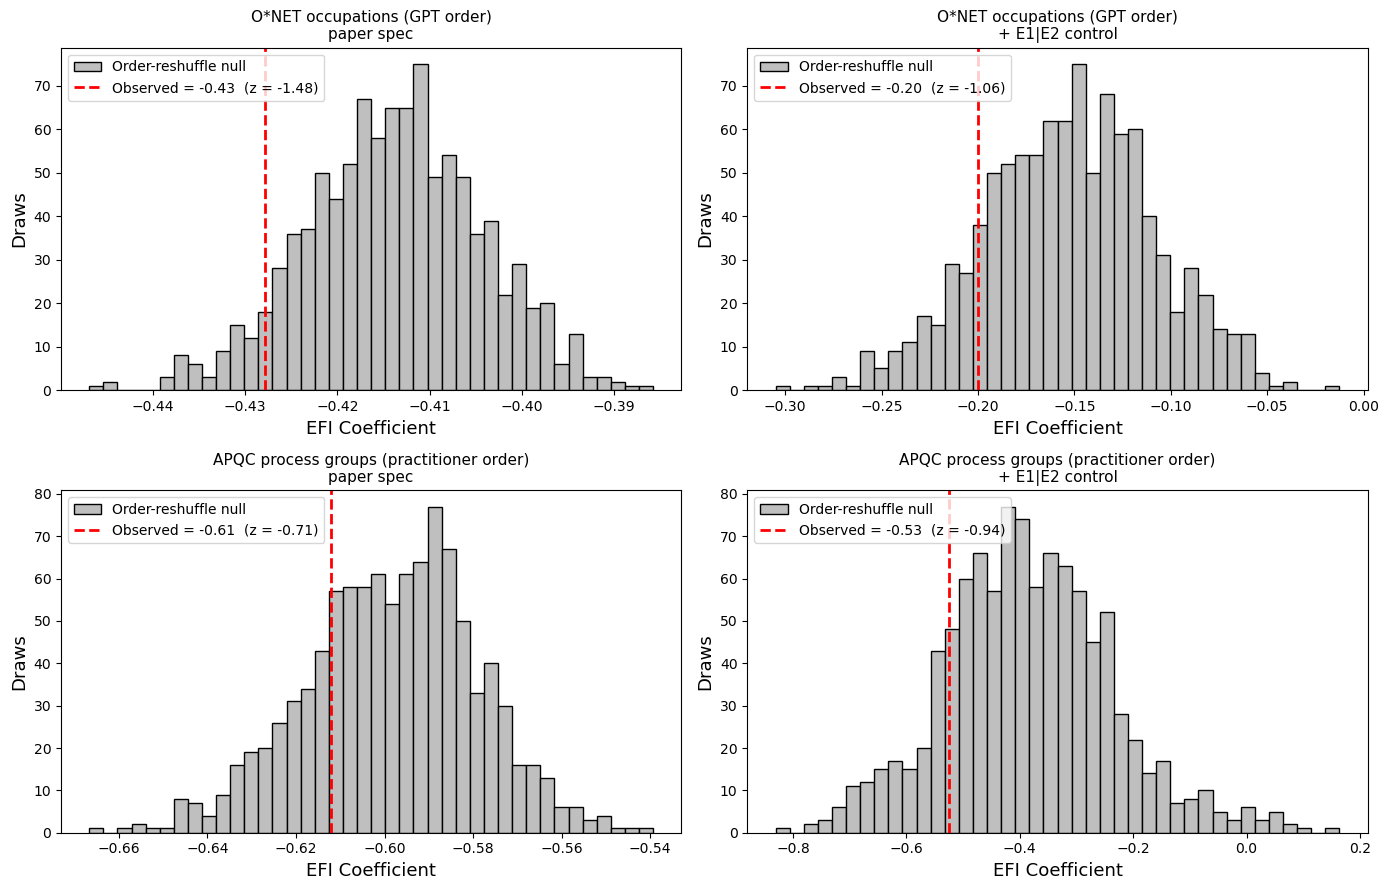

Reading the four panels:
  Under the paper specification the observed coefficient sits inside its own reshuffle null,
  because EFI is largely a transform of the exposure share and randomising order leaves that intact.
  Adding the E1|E2 control removes the composition channel; what is left is the arrangement effect,
  and the question is whether the observed value separates from the null in that panel.


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for i, sname in enumerate(SAMPLES):
    for j, sn in enumerate(SPECS):
        ax = axes[i, j]
        tag = f"{'onet' if 'O*NET' in sname else 'apqc'}_{'paper' if sn == 'paper spec' else 'e12control'}"
        v = pd.read_csv(f"{output_data_path}/placebo_{tag}.csv")['b_efi'].values
        r = nulls[(nulls['sample'] == sname) & (nulls['spec'] == sn)].iloc[0]
        ax.hist(v, bins=40, color='0.75', edgecolor='black', label='Order-reshuffle null')
        ax.axvline(r['observed'], color='red', ls='--', lw=2,
                   label=f"Observed = {r['observed']:+.2f}  (z = {r['z']:+.2f})")
        ax.set_xlabel("EFI Coefficient", fontsize=13)
        ax.set_ylabel("Draws", fontsize=13)
        ax.set_title(f"{sname}\n{sn}", fontsize=11)
        ax.tick_params(labelsize=10); ax.legend(fontsize=10, loc='upper left')
fig.tight_layout()
fig.savefig(f"{output_plot_path}/placebo_composition_vs_arrangement.png", dpi=300, bbox_inches='tight')
plt.show()

print("Reading the four panels:")
print("  Under the paper specification the observed coefficient sits inside its own reshuffle null,")
print("  because EFI is largely a transform of the exposure share and randomising order leaves that intact.")
print("  Adding the E1|E2 control removes the composition channel; what is left is the arrangement effect,")
print("  and the question is whether the observed value separates from the null in that panel.")

# 5) Regression tables

Two tables, written in the format of Table~\ref{tab:fragmentation_index_regression_exposure} in the main
text.

The first is the APQC counterpart of that table: same outcome (the share of steps executed by AI), same two
regressors (the E1 exposure share and EFI Definition~1), same standardisation. The only difference is the
fixed effect. The paper nests occupations in SOC major and minor groups, which gives it two FE columns; APQC
process groups nest only in the thirteen Categories, so there is one.

The second reports the specification that adds the E1$|$E2 share, run on both samples side by side, so the
main specification and its APQC counterpart can be read against each other.

Standard errors are heteroskedasticity-robust (HC1). The published table clusters at the occupation level on
occupation-level data, which is the same object; small differences from the published coefficients come from
dropping the tasks with missing exposure labels.

In [12]:
def star(p):
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''

def cell(m, v):
    return f"{m.params[v]:.2f}{star(m.pvalues[v])}" if v in m.params else ''

def se(m, v):
    return f"({m.bse[v]:.2f})" if v in m.params else ''

def coef_block(label, models, var):
    return ([f"{label} & " + " & ".join(cell(m, var) for m in models) + r" \\",
             " & " + " & ".join(se(m, var) for m in models) + r" \\"])

panel_onet_f = SAMPLES['O*NET occupations (GPT order)'][0]
panel_apqc_f = SAMPLES['APQC process groups (practitioner order)'][0]

# ---------- Table 1: the APQC counterpart of the main fragmentation table ----------
mods = [fit_spec(panel_apqc_f, SPECS['paper spec'], fe) for fe in (False, True)]
tex = [r"\setlength{\tabcolsep}{12pt}", r"\begin{tabular}{lcc}", r"\toprule",
       r" & \multicolumn{2}{c}{EFI Definition 1} \\", r" \cmidrule(lr){2-3}",
       r" & (1) & (2) \\", r"\midrule", r"\addlinespace"]
tex += coef_block("AI Exposure", mods, 'e1') + [r"\addlinespace"]
tex += coef_block("Empirical Fragmentation Index", mods, 'efi')
tex += [r"\hline\\[-1.25em]",
        "R-squared & " + " & ".join(f"{m.rsquared:.2f}" for m in mods) + r" \\",
        "Adj. R-squared & " + " & ".join(f"{m.rsquared_adj:.2f}" for m in mods) + r" \\",
        "Observations & " + " & ".join(f"{int(m.nobs)}" for m in mods) + r" \\",
        r"PCF Category Fixed Effect & & Yes \\", r"\bottomrule",
        r"\multicolumn{3}{l}{\footnotesize Standardized coefficients; robust standard errors in parentheses.} \\",
        r"\multicolumn{3}{l}{\footnotesize $^{*}p<0.1$, $^{**}p<0.05$, $^{***}p<0.01$} \\",
        r"\end{tabular}"]
open(f"{output_table_path}/apqc_fragmentation_index_regression_exposure.tex", 'w').write("\n".join(tex) + "\n")
print("=== Table 1: APQC counterpart ===")
print("\n".join(tex))

=== Table 1: APQC counterpart ===
\setlength{\tabcolsep}{12pt}
\begin{tabular}{lcc}
\toprule
 & \multicolumn{2}{c}{EFI Definition 1} \\
 \cmidrule(lr){2-3}
 & (1) & (2) \\
\midrule
\addlinespace
AI Exposure & -0.22* & -0.06 \\
 & (0.13) & (0.17) \\
\addlinespace
Empirical Fragmentation Index & -0.61*** & -0.47*** \\
 & (0.11) & (0.12) \\
\hline\\[-1.25em]
R-squared & 0.32 & 0.48 \\
Adj. R-squared & 0.30 & 0.36 \\
Observations & 73 & 73 \\
PCF Category Fixed Effect & & Yes \\
\bottomrule
\multicolumn{3}{l}{\footnotesize Standardized coefficients; robust standard errors in parentheses.} \\
\multicolumn{3}{l}{\footnotesize $^{*}p<0.1$, $^{**}p<0.05$, $^{***}p<0.01$} \\
\end{tabular}


In [13]:
# ---------- Table 2: the E1|E2-control specification, both samples side by side ----------
mods2 = ([fit_spec(panel_onet_f, SPECS['+ E1|E2 control'], fe) for fe in (False, True)] +
         [fit_spec(panel_apqc_f, SPECS['+ E1|E2 control'], fe) for fe in (False, True)])

tex2 = [r"\setlength{\tabcolsep}{10pt}", r"\begin{tabular}{lcccc}", r"\toprule",
        r" & \multicolumn{2}{c}{O*NET occupations} & \multicolumn{2}{c}{APQC process groups} \\",
        r"\cmidrule(lr){2-3}\cmidrule(lr){4-5}",
        r" & (1) & (2) & (3) & (4) \\", r"\midrule", r"\addlinespace"]
tex2 += coef_block("AI Exposure (E1)", mods2, 'e1') + [r"\addlinespace"]
tex2 += coef_block("AI Exposure (E1 or E2)", mods2, 'e12') + [r"\addlinespace"]
tex2 += coef_block("Empirical Fragmentation Index", mods2, 'efi')
tex2 += [r"\hline\\[-1.25em]",
         "R-squared & " + " & ".join(f"{m.rsquared:.2f}" for m in mods2) + r" \\",
         "Adj. R-squared & " + " & ".join(f"{m.rsquared_adj:.2f}" for m in mods2) + r" \\",
         "Observations & " + " & ".join(f"{int(m.nobs)}" for m in mods2) + r" \\",
         r"Fixed Effect & & SOC Major & & PCF Category \\", r"\bottomrule",
         r"\multicolumn{5}{l}{\footnotesize Standardized coefficients; robust standard errors in parentheses. Workflow order is the} \\",
         r"\multicolumn{5}{l}{\footnotesize GPT-imputed task sequence in columns (1)--(2) and APQC's documented sequence in (3)--(4).} \\",
         r"\multicolumn{5}{l}{\footnotesize $^{*}p<0.1$, $^{**}p<0.05$, $^{***}p<0.01$} \\",
         r"\end{tabular}"]
open(f"{output_table_path}/fragmentation_index_regression_E1E2control.tex", 'w').write("\n".join(tex2) + "\n")
print("=== Table 2: with the E1|E2 control, both samples ===")
print("\n".join(tex2))

print("\n\n=== the AI-exposure coefficient across every specification ===")
for nm, panel in [('O*NET occupations', panel_onet_f), ('APQC process groups', panel_apqc_f)]:
    for sn, f in SPECS.items():
        for fe in (False, True):
            m = fit_spec(panel, f, fe)
            print(f"  {nm:<20}{sn:<18}{'FE' if fe else 'No FE':<7} "
                  f"E1 {m.params['e1']:+.3f}{star(m.pvalues['e1']):<4}"
                  + (f"  E1|E2 {m.params['e12']:+.3f}{star(m.pvalues['e12'])}" if 'e12' in m.params else ''))

print("\n=== why the sign differs: raw correlations with the AI-execution share ===")
for nm, panel in [('O*NET occupations', panel_onet_f), ('APQC process groups', panel_apqc_f)]:
    c = panel[['ai', 'e1', 'e12', 'efi']].corr()['ai']
    print(f"  {nm:<20} corr(ai, E1) {c['e1']:+.3f} | corr(ai, E1|E2) {c['e12']:+.3f} | corr(ai, EFI) {c['efi']:+.3f}")
    print(f"  {'':<20} E1 share: mean {panel['e1'].mean():.3f}, sd {panel['e1'].std():.3f} | "
          f"E1|E2 share: mean {panel['e12'].mean():.3f}, sd {panel['e12'].std():.3f}")

=== Table 2: with the E1|E2 control, both samples ===
\setlength{\tabcolsep}{10pt}
\begin{tabular}{lcccc}
\toprule
 & \multicolumn{2}{c}{O*NET occupations} & \multicolumn{2}{c}{APQC process groups} \\
\cmidrule(lr){2-3}\cmidrule(lr){4-5}
 & (1) & (2) & (3) & (4) \\
\midrule
\addlinespace
AI Exposure (E1) & 0.20*** & 0.08** & -0.23* & -0.07 \\
 & (0.04) & (0.04) & (0.13) & (0.17) \\
\addlinespace
AI Exposure (E1 or E2) & 0.26*** & 0.26*** & 0.09 & 0.16 \\
 & (0.08) & (0.08) & (0.28) & (0.30) \\
\addlinespace
Empirical Fragmentation Index & -0.20** & -0.15* & -0.53** & -0.34 \\
 & (0.09) & (0.09) & (0.26) & (0.28) \\
\hline\\[-1.25em]
R-squared & 0.38 & 0.62 & 0.32 & 0.48 \\
Adj. R-squared & 0.38 & 0.61 & 0.29 & 0.35 \\
Observations & 871 & 871 & 73 & 73 \\
Fixed Effect & & SOC Major & & PCF Category \\
\bottomrule
\multicolumn{5}{l}{\footnotesize Standardized coefficients; robust standard errors in parentheses. Workflow order is the} \\
\multicolumn{5}{l}{\footnotesize GPT-imputed task 

# 6) Redefining exposure as E1$|$E2 in the main specification

The paper's estimating equation controls for the E1 share while EFI Definition~1 is built from E1 or E2, so
the two objects are defined off different label sets. This section asks what happens if exposure is defined
the same way the fragmentation index is, replacing the E1 share with the E1$|$E2 share throughout.

Three specifications are compared on both samples:

* **A. Paper specification** — exposure is the E1 share.
* **B. Matched definition** — exposure is the E1$|$E2 share, the same labels that build EFI.
* **C. Both** — the E1 and E1$|$E2 shares enter together, as in the previous section.

Specification B is the one to watch. Because EFI is approximately $1 - p^2$ in the E1$|$E2 share $p$, putting
$p$ on the right-hand side alongside EFI asks the regression to separate two nearly collinear objects, so the
diagnostics below report how much independent variation is left.

In [14]:
SPECS3 = {'A. paper (E1)':        'ai ~ efi + e1',
          'B. matched (E1|E2)':   'ai ~ efi + e12',
          'C. both':              'ai ~ efi + e1 + e12'}

rows = []
for sname, (panel, seqs) in SAMPLES.items():
    for sn, f in SPECS3.items():
        for fe in (False, True):
            m = fit_spec(panel, f, fe)
            rows.append({'sample': sname, 'spec': sn, 'fe': 'FE' if fe else 'No FE', 'n': int(m.nobs),
                         'b_efi': m.params['efi'], 'se_efi': m.bse['efi'], 'p_efi': m.pvalues['efi'],
                         'b_e1': m.params.get('e1', np.nan), 'p_e1': m.pvalues.get('e1', np.nan),
                         'b_e12': m.params.get('e12', np.nan), 'p_e12': m.pvalues.get('e12', np.nan),
                         'r2': m.rsquared})
grid = pd.DataFrame(rows)
grid.to_csv(f"{output_data_path}/exposure_definition_grid.csv", index=False)

for sname in SAMPLES:
    print(f"=== {sname} ===")
    print(f"{'spec':<22}{'FE':<7}{'EFI':>14}{'E1':>14}{'E1|E2':>14}{'R2':>8}")
    for _, r in grid[grid['sample'] == sname].iterrows():
        e1 = '' if pd.isna(r['b_e1']) else f"{r['b_e1']:+.3f}{star(r['p_e1'])}"
        e12 = '' if pd.isna(r['b_e12']) else f"{r['b_e12']:+.3f}{star(r['p_e12'])}"
        print(f"{r['spec']:<22}{r['fe']:<7}{r['b_efi']:>+10.3f}{star(r['p_efi']):<4}{e1:>14}{e12:>14}{r['r2']:>8.3f}")
    print()

print("=== how much independent variation is left in spec B? ===")
for sname, (panel, seqs) in SAMPLES.items():
    r2 = smf.ols('efi ~ e12', data=panel).fit().rsquared
    print(f"  {sname:<44} R2(EFI on E1|E2) = {r2:.3f} | VIF = {1/(1-r2):6.1f} | "
          f"corr = {panel[['efi','e12']].corr().iloc[0,1]:+.3f}")

=== O*NET occupations (GPT order) ===
spec                  FE                EFI            E1         E1|E2      R2
A. paper (E1)         No FE      -0.428***      +0.232***                 0.378
A. paper (E1)         FE         -0.359***       +0.098**                 0.615
B. matched (E1|E2)    No FE      -0.211**                     +0.399***   0.365
B. matched (E1|E2)    FE         -0.165*                      +0.301***   0.616
C. both               No FE      -0.200**       +0.201***     +0.261***   0.383
C. both               FE         -0.153*         +0.081**     +0.262***   0.619

=== APQC process groups (practitioner order) ===
spec                  FE                EFI            E1         E1|E2      R2
A. paper (E1)         No FE      -0.612***        -0.217*                 0.322
A. paper (E1)         FE         -0.473***         -0.057                 0.483
B. matched (E1|E2)    No FE      -0.588**                        -0.061   0.281
B. matched (E1|E2)    FE        

Order-reshuffle placebo on the EFI coefficient, by exposure definition

sample                                      spec                    observed     null      sd      z       p
O*NET occupations (GPT order)               A. paper (E1)             -0.428   -0.414   0.009  -1.48  0.0669
O*NET occupations (GPT order)               B. matched (E1|E2)        -0.211   -0.165   0.045  -1.02  0.1518
O*NET occupations (GPT order)               C. both                   -0.200   -0.153   0.044  -1.06  0.1449
APQC process groups (practitioner order)    A. paper (E1)             -0.612   -0.598   0.019  -0.71  0.2278
APQC process groups (practitioner order)    B. matched (E1|E2)        -0.588   -0.435   0.144  -1.06  0.1299
APQC process groups (practitioner order)    C. both                   -0.525   -0.385   0.149  -0.94  0.1568


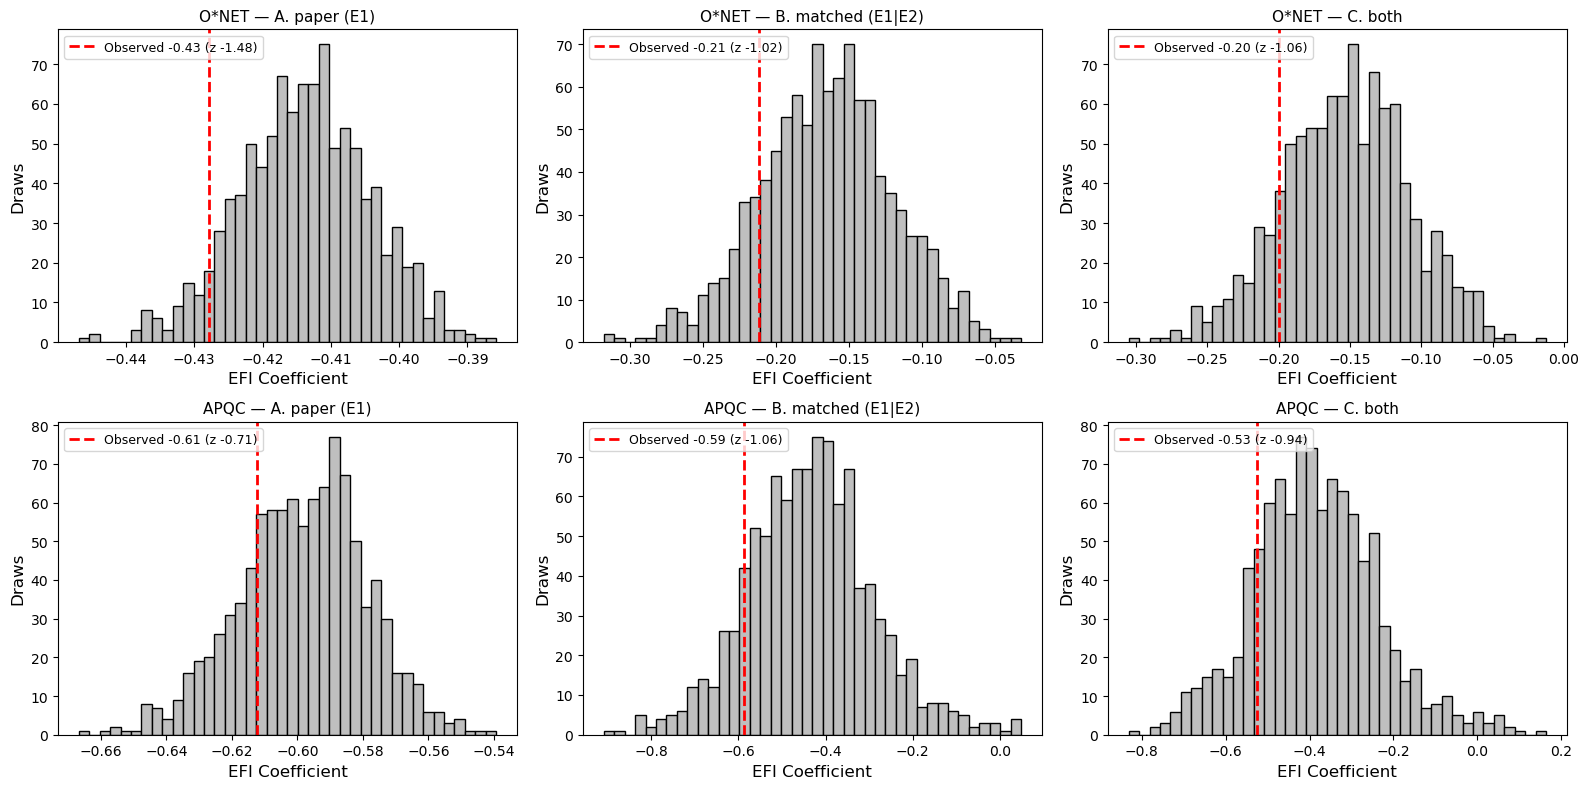

In [15]:
# Placebo for the matched-definition specification, alongside the other two
rng = np.random.default_rng(42)
pl_rows = []
for sname, (panel, seqs) in SAMPLES.items():
    arrays = [seqs[u] for u in panel['unit']]
    draws = {sn: [] for sn in SPECS3}
    for _ in range(N_DRAWS):
        p = panel.assign(efi=np.array([efi_from(rng.permutation(a)) for a in arrays]))
        for sn, f in SPECS3.items():
            draws[sn].append(fit_spec(p, f).params['efi'])
    for sn in SPECS3:
        v = np.array(draws[sn])
        o = grid[(grid['sample'] == sname) & (grid['spec'] == sn) & (grid['fe'] == 'No FE')]['b_efi'].iloc[0]
        pl_rows.append({'sample': sname, 'spec': sn, 'observed': o, 'null_mean': v.mean(),
                        'null_sd': v.std(ddof=1), 'z': (o - v.mean()) / v.std(ddof=1),
                        'p': (1 + int((v <= o).sum())) / (1 + N_DRAWS)})
        pd.DataFrame({'b_efi': v}).to_csv(
            f"{output_data_path}/placebo_grid_{'onet' if 'O*NET' in sname else 'apqc'}_{sn[0]}.csv", index=False)

pl = pd.DataFrame(pl_rows)
pl.to_csv(f"{output_data_path}/exposure_definition_placebo.csv", index=False)
print("Order-reshuffle placebo on the EFI coefficient, by exposure definition\n")
print(f"{'sample':<44}{'spec':<22}{'observed':>10}{'null':>9}{'sd':>8}{'z':>7}{'p':>8}")
for _, r in pl.iterrows():
    print(f"{r['sample']:<44}{r['spec']:<22}{r['observed']:>10.3f}{r['null_mean']:>9.3f}"
          f"{r['null_sd']:>8.3f}{r['z']:>7.2f}{r['p']:>8.4f}")

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, sname in enumerate(SAMPLES):
    for j, sn in enumerate(SPECS3):
        ax = axes[i, j]
        v = pd.read_csv(f"{output_data_path}/placebo_grid_"
                        f"{'onet' if 'O*NET' in sname else 'apqc'}_{sn[0]}.csv")['b_efi'].values
        r = pl[(pl['sample'] == sname) & (pl['spec'] == sn)].iloc[0]
        ax.hist(v, bins=40, color='0.75', edgecolor='black')
        ax.axvline(r['observed'], color='red', ls='--', lw=2,
                   label=f"Observed {r['observed']:+.2f} (z {r['z']:+.2f})")
        ax.set_title(f"{'O*NET' if 'O*NET' in sname else 'APQC'} — {sn}", fontsize=11)
        ax.set_xlabel("EFI Coefficient", fontsize=12); ax.set_ylabel("Draws", fontsize=12)
        ax.tick_params(labelsize=10); ax.legend(fontsize=9, loc='upper left')
fig.tight_layout()
fig.savefig(f"{output_plot_path}/placebo_by_exposure_definition.png", dpi=300, bbox_inches='tight')
plt.show()